In [1]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [2]:
#Set plotting and notebook options
output_divider = '=' * 90
plt.style.use('seaborn-v0_8')
%matplotlib inline
fontsize=12
fontweight='bold'

In [3]:
#Part One: EDA

In [4]:
print("Load Dataset:")
print(output_divider)
df = pd.read_csv(r"C:\Users\natha\OneDrive\Documents\DataSets\Customer-Churn-Records.csv")
print("First five rows of data:")
print(output_divider)
df.head()

Load Dataset:
First five rows of data:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
print("Dataframe shape:", df.shape, '|', "DataFrame Size:", df.size)
print(output_divider)
print("Data Types and Initial Missing Data Inspection:")
print(output_divider)
df.info()

Dataframe shape: (10000, 18) | DataFrame Size: 180000
Data Types and Initial Missing Data Inspection:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  C

In [6]:
print("Summary Level Statistics:")
df.describe()

Summary Level Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
print("Missing Data By Column:")
df.isna().sum()

Missing Data By Column:


RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [8]:
#Categorical Data Inspection

In [9]:
objects = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:")
print(objects)

Categorical Features:
['Surname', 'Geography', 'Gender', 'Card Type']


In [10]:
print("Customer Surnames:", df['Surname'].nunique())
print(output_divider)
print("Unique Geographies Count:", df['Geography'].nunique())
print(output_divider)
print("Unique Genders Count:", df['Gender'].nunique())
print(output_divider)
print("Unique Card Types", df['Card Type'].nunique())

Customer Surnames: 2932
Unique Geographies Count: 3
Unique Genders Count: 2
Unique Card Types 4


In [11]:
#Review categorical data for spelling, spacing, capitalization
print("Geographic Regions:", df['Geography'].unique().tolist())
print(output_divider)
print("Genders:", df['Gender'].unique().tolist())
print(output_divider)
print("Card Types:", df['Card Type'].unique().tolist())
print(output_divider)

Geographic Regions: ['France', 'Spain', 'Germany']
Genders: ['Female', 'Male']
Card Types: ['DIAMOND', 'GOLD', 'SILVER', 'PLATINUM']


In [12]:
#Standardize capitalization on card type categorical feature
df['Card Type'] = df['Card Type'].str.capitalize()
print(df['Card Type'].unique().tolist())

['Diamond', 'Gold', 'Silver', 'Platinum']


In [13]:
#Rename features and create churn categorical feature for EDA plotting
df['Churn'] = df['Exited']
df = df.drop(['Exited'], axis=1)
df['Customer_Churn'] = df['Churn'].map({0: 'No', 1: 'Yes'})
print("Review Header Before Descriptive Analytics:")
df.head()

Review Header Before Descriptive Analytics:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Churn,Customer_Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,Diamond,464,1,Yes
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1,3,Diamond,456,0,No
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,Diamond,377,1,Yes
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,Gold,350,0,No
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,Gold,425,0,No


In [14]:
#Part Two: Visualization EDA

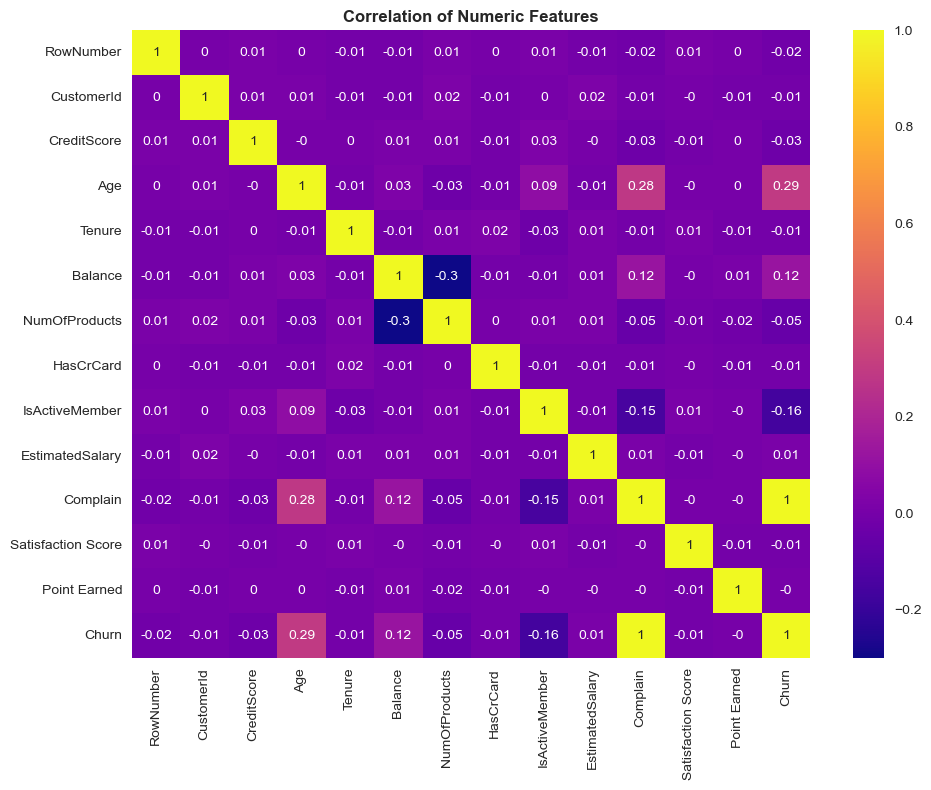

In [15]:
#Create heatmap to understand feature correlations
corr = df.select_dtypes(include=['int64', 'float64']).corr().round(2)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='plasma', annot=True)
plt.title("Correlation of Numeric Features", fontsize=fontsize, fontweight=fontweight)
plt.tight_layout()
plt.show()

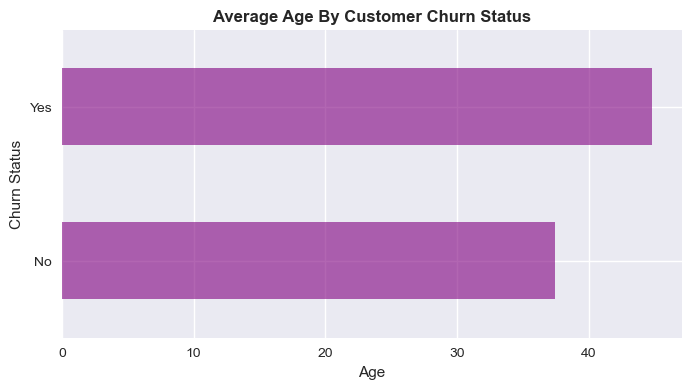

In [16]:
churn_age = df.groupby('Customer_Churn')['Age'].mean()
plt.figure(figsize=(8,4))
churn_age.plot(kind='barh', color='purple', alpha=0.6)
plt.title("Average Age By Customer Churn Status", fontweight=fontweight, fontsize=fontsize)
plt.xlabel("Age")
plt.ylabel("Churn Status")
plt.show()

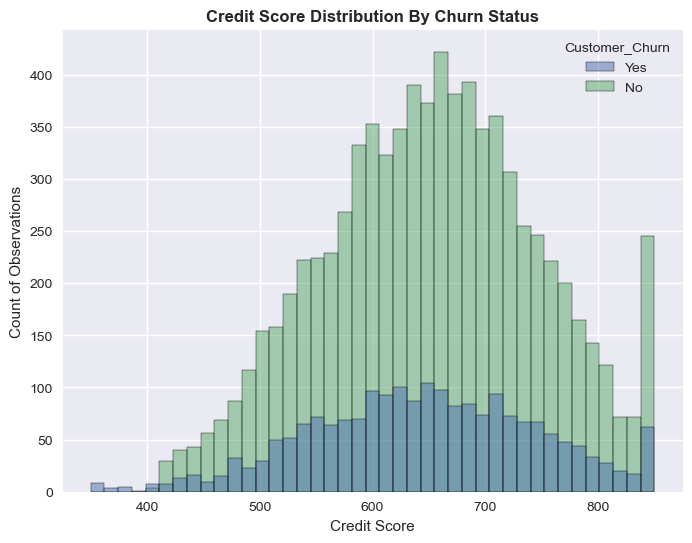

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='CreditScore', hue='Customer_Churn')
plt.title("Credit Score Distribution By Churn Status", fontweight=fontweight, fontsize=fontsize)
plt.xlabel("Credit Score")
plt.ylabel("Count of Observations")
plt.show()

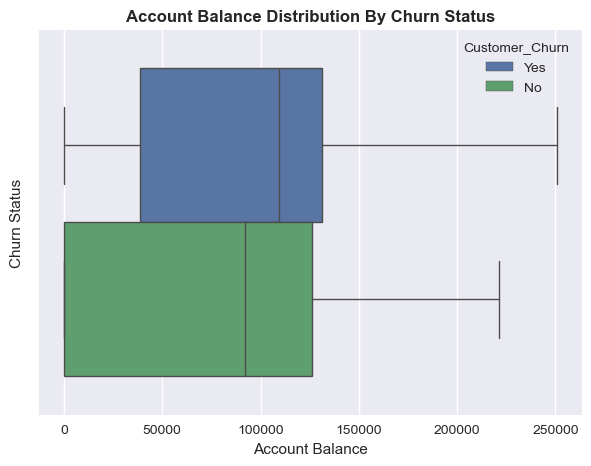

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Balance', hue='Customer_Churn')
plt.title("Account Balance Distribution By Churn Status", fontsize=fontsize, fontweight=fontweight)
plt.xlabel("Account Balance")
plt.ylabel("Churn Status")
plt.show()

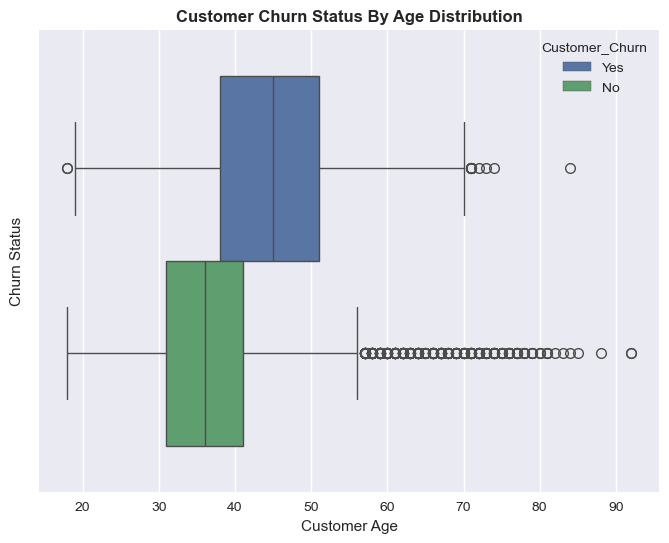

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Age', hue='Customer_Churn')
plt.title('Customer Churn Status By Age Distribution', fontsize=fontsize, fontweight=fontweight)
plt.xlabel("Customer Age")
plt.ylabel("Churn Status")
plt.show()

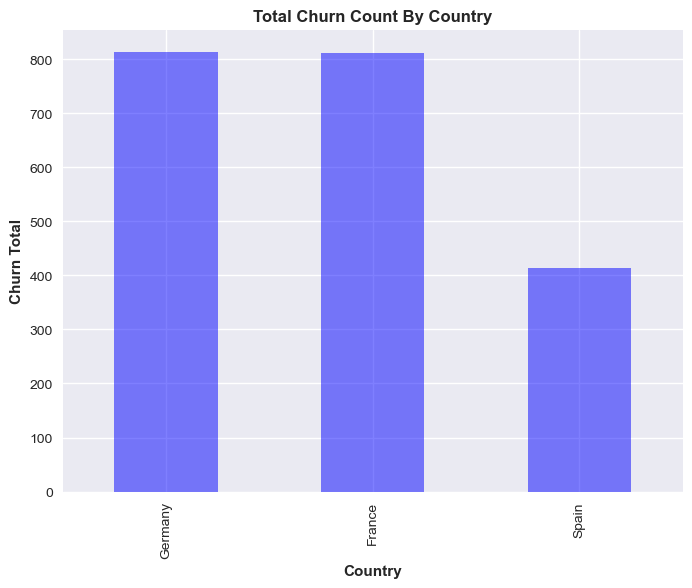

In [20]:
churn_only = df.query("Customer_Churn == 'Yes'")
region_churn = churn_only.groupby('Geography')['Customer_Churn'].count().sort_values(ascending=False)
plt.figure(figsize=(8,6))
region_churn.plot(kind='bar', color='blue', alpha=0.5)
plt.title("Total Churn Count By Country", fontweight=fontweight, fontsize=fontsize)
plt.xlabel("Country", fontweight='bold')
plt.ylabel("Churn Total", fontweight='bold')
plt.show()

In [21]:
#Part 3: Machine Learning

In [22]:
#3A: Data Preparation

In [23]:
#Establish X and y
X = df.drop('Customer_Churn', axis=1)
y = df['Churn']

In [24]:
#Remove Unneeded Features
X = X.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Churn', 'Complain'], axis=1)

In [25]:
print("X Features:")
print(output_divider)
print(X.columns.tolist())
print(output_divider)
print("X Header:")
X.head()

X Features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Card Type', 'Point Earned']
X Header:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,2,Diamond,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,3,Diamond,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,3,Diamond,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,5,Gold,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,5,Gold,425


In [26]:
cat_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical Features:")
print(cat_features)
print(output_divider)
print("Numeric Features:")
print(numeric_features)

Categorical Features:
['Geography', 'Gender', 'Card Type']
Numeric Features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']


In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, cat_features)])

In [28]:
#Establish training/test data and standardize random_state/cross validations
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=random_state, test_size=0.2)
cv = KFold(shuffle=True, n_splits=5, random_state=random_state)

In [29]:
#3B: Logistic Regression

In [30]:
#Establish Logistic Regression Classifer as first model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LogisticRegression', LogisticRegression(random_state=random_state))])

In [31]:
LogReg_CrossVal_Scores = cross_val_score(pipeline, X_train, y_train, scoring='f1', cv=cv)
LogReg_CrossVal_Mean = LogReg_CrossVal_Scores.mean()
print("Logistic Regression Cross Validation Scores:", LogReg_CrossVal_Scores)
print(output_divider)
print("Logistic Regression Mean Cross Validation F1 Score:", LogReg_CrossVal_Mean)

Logistic Regression Cross Validation Scores: [0.30839002 0.32173913 0.35346756 0.3375     0.26960784]
Logistic Regression Mean Cross Validation F1 Score: 0.3181409115538054


In [32]:
#3C: Random Forest Classifier

In [33]:
#Establish Random Forest Classifier as second model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Random_Forest', RandomForestClassifier(random_state=random_state, n_estimators=100, max_depth=5))])

In [34]:
RF_Untuned_CrossVal_Scores = cross_val_score(pipeline, X_train, y_train, scoring='f1', cv=cv)
RF_Untuned_CrossVal_Mean = RF_Untuned_CrossVal_Scores.mean()
print("Initial Random Forest Cross Validation Scores:", RF_Untuned_CrossVal_Scores)
print(output_divider)
print("Initial Random Forest Cross Validation Mean F1 Score:", RF_Untuned_CrossVal_Mean)

Initial Random Forest Cross Validation Scores: [0.41108545 0.42825607 0.39036145 0.39823009 0.359375  ]
Initial Random Forest Cross Validation Mean F1 Score: 0.39746161105306094


In [35]:
#3D: Random Forest Hyperparameter Tuning

In [36]:
param_grid = {'Random_Forest__n_estimators': [75,100,125],
              'Random_Forest__max_depth': [8,10,12]}
param_search = GridSearchCV(pipeline, param_grid, scoring='f1', verbose=2)
param_search.fit(X_train, y_train)
print(output_divider)
print("Best Parameters:", param_search.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=75; total time=   1.4s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=75; total time=   1.4s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=75; total time=   1.3s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=75; total time=   1.3s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=75; total time=   1.3s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=100; total time=   1.8s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=100; total time=   1.8s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=100; total time=   2.0s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=100; total time=   1.8s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_estimators=100; total time=   1.8s
[CV] END Random_Forest__max_depth=8, Random_Forest__n_e

In [37]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Random_Forest', RandomForestClassifier(random_state=random_state, n_estimators=75, max_depth=12))])

In [38]:
RF_Tuned_CrossVal = cross_val_score(pipeline, X_train, y_train, cv=cv)
RF_Tuned_CrossVal_Mean = RF_Tuned_CrossVal.mean()
print('Tuned Random Forest Cross Val Scores:', RF_Tuned_CrossVal)
print(output_divider)
print("Tuned Random Forest Mean Cross Validation F1 Score:", RF_Tuned_CrossVal_Mean)

Tuned Random Forest Cross Val Scores: [0.86625  0.855    0.869375 0.85625  0.8725  ]
Tuned Random Forest Mean Cross Validation F1 Score: 0.8638750000000002


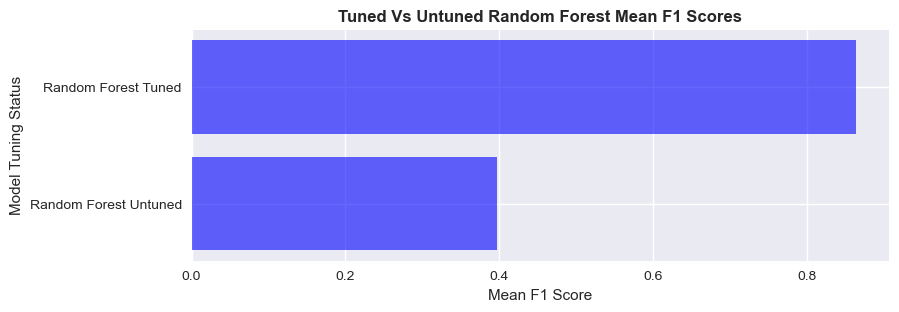

Hyperparameter tuning proved to significantly improve Random Forest performance.


In [39]:
scores = [RF_Untuned_CrossVal_Mean, RF_Tuned_CrossVal_Mean]
models= ['Random Forest Untuned', 'Random Forest Tuned']
plt.figure(figsize=(9,3))
plt.barh(models, scores,
         color='blue', alpha=0.60)
plt.title("Tuned Vs Untuned Random Forest Mean F1 Scores", fontweight=fontweight,
          fontsize=fontsize)
plt.xlabel("Mean F1 Score")
plt.ylabel("Model Tuning Status")
plt.show()
print(output_divider)
comments = 'Hyperparameter tuning proved to significantly improve Random Forest performance.'
print(comments)

In [40]:
#3E: Fit Random Forest Model

In [41]:
print("Fit model to pipeline:")
pipeline.fit(X_train, y_train)

Fit model to pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Random_Forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [42]:
#3F: Predictions And Model Evaluation

In [43]:
y_pred = pipeline.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_pred, y_test))
print(output_divider)
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Random Forest Confusion Matrix:", confusion_matrix)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.92      1775
           1       0.43      0.75      0.54       225

    accuracy                           0.86      2000
   macro avg       0.70      0.81      0.73      2000
weighted avg       0.90      0.86      0.87      2000

Random Forest Confusion Matrix: [[1550   57]
 [ 225  168]]


In [44]:
#3G: Random Forest Feature Evaluation

In [45]:
rf_values = pipeline.named_steps['Random_Forest'].feature_importances_
rf_features = pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_feature_values = pd.Series(rf_values, index=rf_features).sort_values()

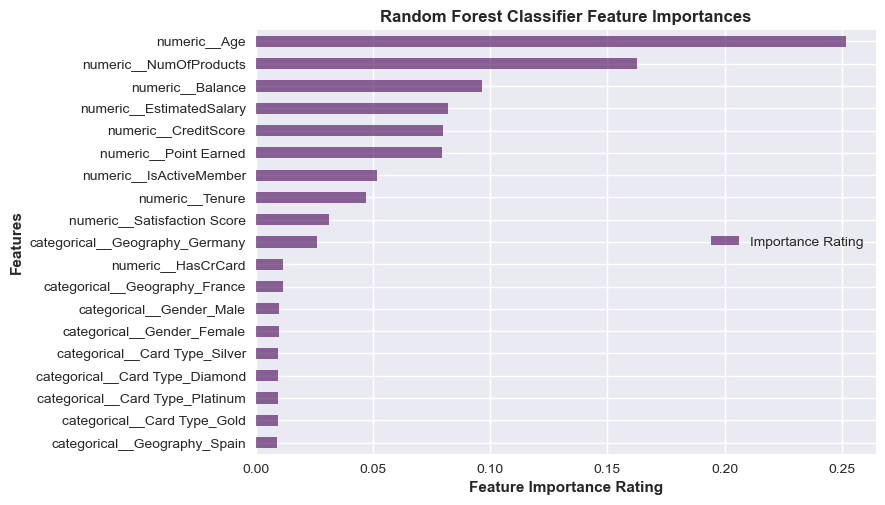

In [46]:
rf_feature_values.plot(kind='barh', cmap='viridis', alpha=0.6, label='Importance Rating')
plt.title("Random Forest Classifier Feature Importances", fontweight=fontweight, fontsize=fontsize)
plt.legend(loc='center right')
plt.xlabel("Feature Importance Rating", fontweight=fontweight)
plt.ylabel("Features", fontweight=fontweight)
plt.show()

In [47]:
#End of notebook